In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
raw = pd.read_csv("../data/raw/nyc311_2025_sample.csv")

In [5]:
raw.head()

,unique_key,created_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,borough,city,latitude,longitude,closed_date
0,63577994,2025-01-01T00:00:12.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10466.0,BRONX,BRONX,40.891872,-73.860168,2025-01-02T17:05:54.000
1,63584096,2025-01-01T00:00:13.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11211.0,BROOKLYN,BROOKLYN,40.711210,-73.958973,2025-01-01T00:05:19.000
2,63581480,2025-01-01T00:00:17.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10466.0,BRONX,BRONX,40.891872,-73.860168,2025-01-01T09:01:06.000
3,63575612,2025-01-01T00:00:19.000,NYPD,New York City Police Department,Illegal Fireworks,NaN,Street/Sidewalk,11230.0,BROOKLYN,BROOKLYN,40.629240,-73.968790,2025-01-01T00:43:08.000
4,63586536,2025-01-01T00:00:34.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,RESIDENTIAL BUILDING,10466.0,BRONX,BRONX,40.891940,-73.852775,2025-01-02T12:04:30.000


In [6]:
raw.shape

(100000, 13)

In [7]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   unique_key      100000 non-null  int64  
 1   created_date    100000 non-null  object 
 2   agency          100000 non-null  object 
 3   agency_name     100000 non-null  object 
 4   complaint_type  100000 non-null  object 
 5   descriptor      98782 non-null   object 
 6   location_type   92031 non-null   object 
 7   incident_zip    99527 non-null   float64
 8   borough         100000 non-null  object 
 9   city            97700 non-null   object 
 10  latitude        99206 non-null   float64
 11  longitude       99206 non-null   float64
 12  closed_date     100000 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 9.9+ MB


In [8]:
raw.describe()

,unique_key,incident_zip,latitude,longitude
count,1.000000e+05,99527.000000,99206.000000,99206.000000
mean,6.363687e+07,10720.423342,40.779239,-73.906001
std,3.514626e+04,482.960463,0.099871,0.067994
min,6.357209e+07,7307.000000,40.500889,-74.253178
25%,6.361069e+07,10458.000000,40.692051,-73.950324
50%,6.363674e+07,10466.000000,40.797731,-73.897531
75%,6.366275e+07,11221.000000,40.891872,-73.860168
max,6.907434e+07,11694.000000,40.911829,-73.701665


In [9]:
raw.isnull().sum()

unique_key           0
created_date         0
agency               0
agency_name          0
complaint_type       0
descriptor        1218
location_type     7969
incident_zip       473
borough              0
city              2300
latitude           794
longitude          794
closed_date          0
dtype: int64

In [10]:
raw.duplicated().sum()

np.int64(0)

In [11]:
created = pd.to_datetime(raw["created_date"])
closed = pd.to_datetime(raw["closed_date"])

resolution_days = (closed - created).dt.total_seconds() / (24 * 60 * 60)

In [12]:
resolution_days.describe()

count    100000.000000
mean          8.386056
std          32.876383
min          -2.243750
25%           0.078238
50%           0.509508
75%           1.990162
max         603.805347
dtype: float64

In [13]:
negative_time = (resolution_days < 0).sum()

In [14]:
zero_resolution_time = (resolution_days == 0).sum()

In [15]:
over_7_days = (resolution_days > 7).sum()
over_30_days = (resolution_days > 30).sum()
over_90_days = (resolution_days > 90).sum()
over_365_days = (resolution_days > 365).sum()

In [16]:
print("Negative resolution times:", negative_time)
print("Zero resolution times:", zero_resolution_time)
print("Resolution times > 7 days:", over_7_days)
print("Resolution times > 30 days:", over_30_days)
print("Resolution times > 90 days:", over_90_days)
print("Resolution times > 365 days:", over_365_days)

Negative resolution times: 2
Zero resolution times: 789
Resolution times > 7 days: 12051
Resolution times > 30 days: 6633
Resolution times > 90 days: 2707
Resolution times > 365 days: 109


In [17]:
delay_flag = (resolution_days > 7).astype(int)

print("Class counts:")
print(delay_flag.value_counts())
print("\nClass percentages:")
print(delay_flag.value_counts(normalize=True) * 100)

Class counts:
0    87949
1    12051
Name: count, dtype: int64

Class percentages:
0    87.949
1    12.051
Name: proportion, dtype: float64


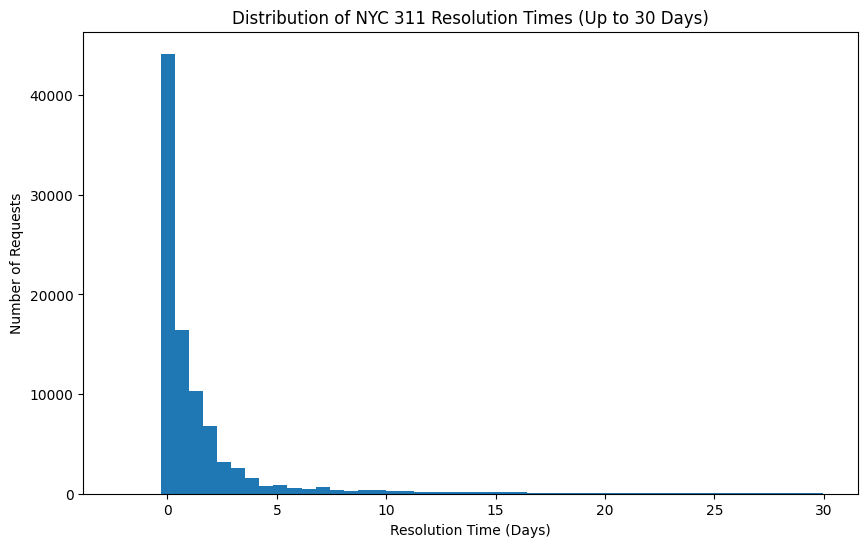

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    resolution_days[resolution_days <= 30],
    bins=50
)

plt.xlabel("Resolution Time (Days)")
plt.ylabel("Number of Requests")
plt.title("Distribution of NYC 311 Resolution Times (Up to 30 Days)")

plt.show()

Observation: The resolution-time distribution is strongly right-skewed. Most NYC 311 requests in the 
sample are resolved within a short period, while a smaller number take considerably longer to resolve. 
This long right tail indicates the presence of long-running requests and motivates using the 7-day 
threshold to define delayed requests.

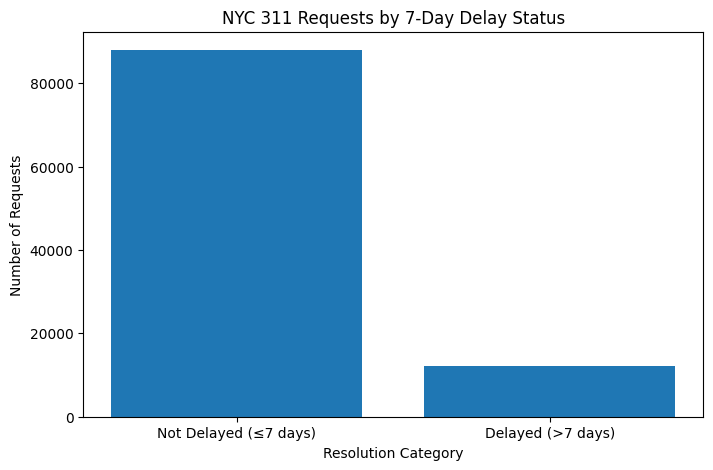

In [19]:
delay_counts = delay_flag.value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Not Delayed (≤7 days)", "Delayed (>7 days)"],
    delay_counts.values
)

plt.xlabel("Resolution Category")
plt.ylabel("Number of Requests")
plt.title("NYC 311 Requests by 7-Day Delay Status")

plt.show()

In [20]:
agency_summary = (
    pd.DataFrame({
        "agency": raw["agency"],
        "delay_flag": delay_flag
    })
    .groupby("agency")
    .agg(
        total_requests=("delay_flag", "count"),
        delayed_requests=("delay_flag", "sum")
    )
)

agency_summary["delay_rate"] = (
    agency_summary["delayed_requests"]
    / agency_summary["total_requests"]
    * 100
)

agency_summary = agency_summary.sort_values(
    "delay_rate",
    ascending=False
)

agency_summary

,total_requests,delayed_requests,delay_rate
agency,,,
EDC,483,483,100.000000
TLC,599,460,76.794658
DOE,79,60,75.949367
DPR,1017,520,51.130777
OTI,8,4,50.000000
DOB,1867,854,45.741832
DCWP,330,146,44.242424
DOHMH,1400,541,38.642857
DHS,240,78,32.500000


### Delay Rate by Agency

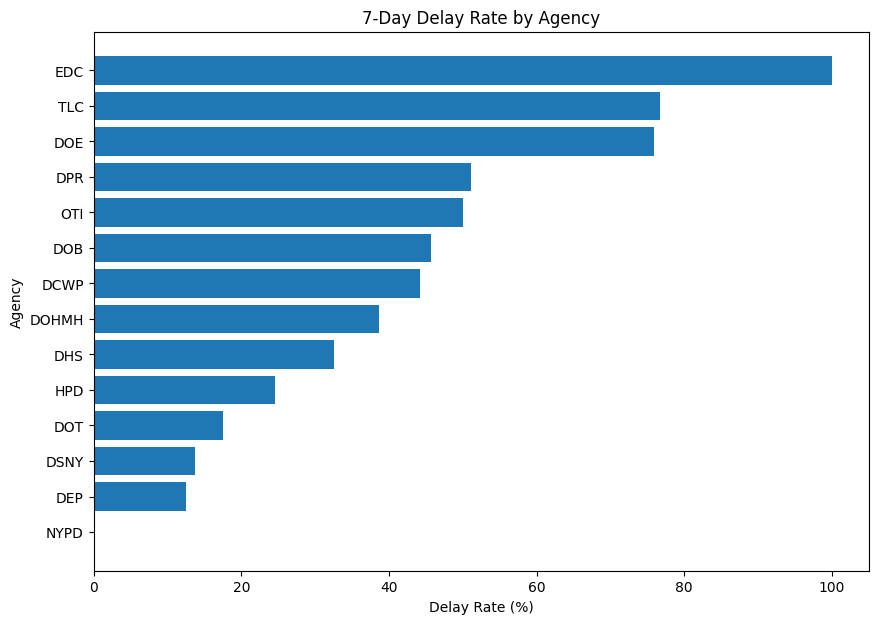

In [21]:
plt.figure(figsize=(10, 7))

plt.barh(
    agency_summary.index,
    agency_summary["delay_rate"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Agency")
plt.title("7-Day Delay Rate by Agency")
plt.gca().invert_yaxis()

plt.show()

## 7. Complaint Type Analysis

### 7.1 Request Volume by Complaint Type


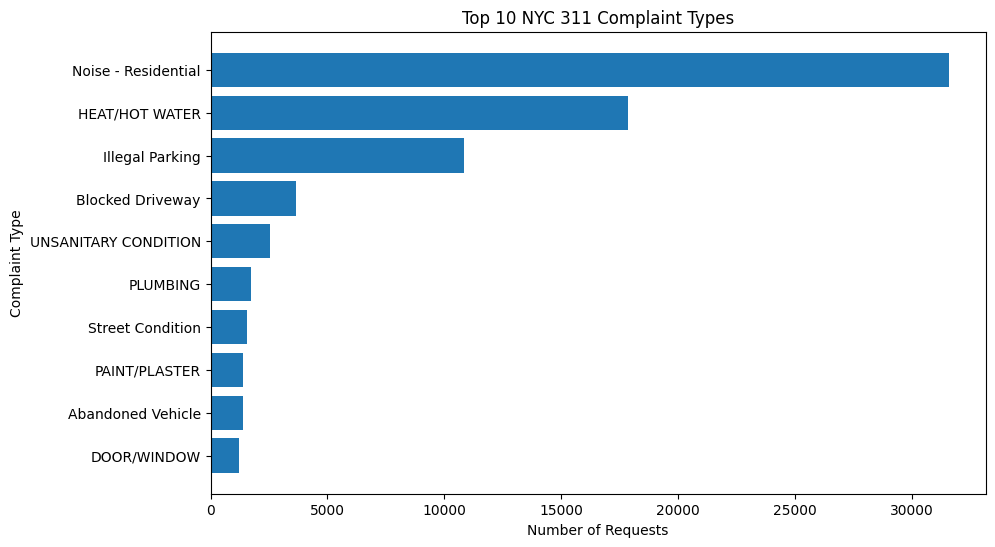

In [22]:
complaint_counts = raw["complaint_type"].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    complaint_counts.index[::-1],
    complaint_counts.values[::-1]
)

plt.xlabel("Number of Requests")
plt.ylabel("Complaint Type")
plt.title("Top 10 NYC 311 Complaint Types")

plt.show()

### 7.2 Delay Rate by Complaint Type

In [23]:
complaint_summary = (
    pd.DataFrame({
        "complaint_type": raw["complaint_type"],
        "delay_flag": delay_flag
    })
    .groupby("complaint_type")
    .agg(
        total_requests=("delay_flag", "count"),
        delayed_requests=("delay_flag", "sum")
    )
)

complaint_summary["delay_rate"] = (
    complaint_summary["delayed_requests"]
    / complaint_summary["total_requests"]
    * 100
)

complaint_summary_filtered = complaint_summary[
    complaint_summary["total_requests"] >= 100
].sort_values(
    "delay_rate",
    ascending=False
)

complaint_summary_filtered.head(15)

,total_requests,delayed_requests,delay_rate
complaint_type,,,
Smoking or Vaping,142,142,100.000000
Noise - Helicopter,483,483,100.000000
Taxi Complaint,140,139,99.285714
For Hire Vehicle Complaint,318,314,98.742138
Root/Sewer/Sidewalk Condition,142,138,97.183099
Non-Residential Heat,114,110,96.491228
Food Establishment,232,189,81.465517
Graffiti,378,302,79.894180
Building/Use,346,262,75.722543


### Visualize Complaint-Type Delay Rate

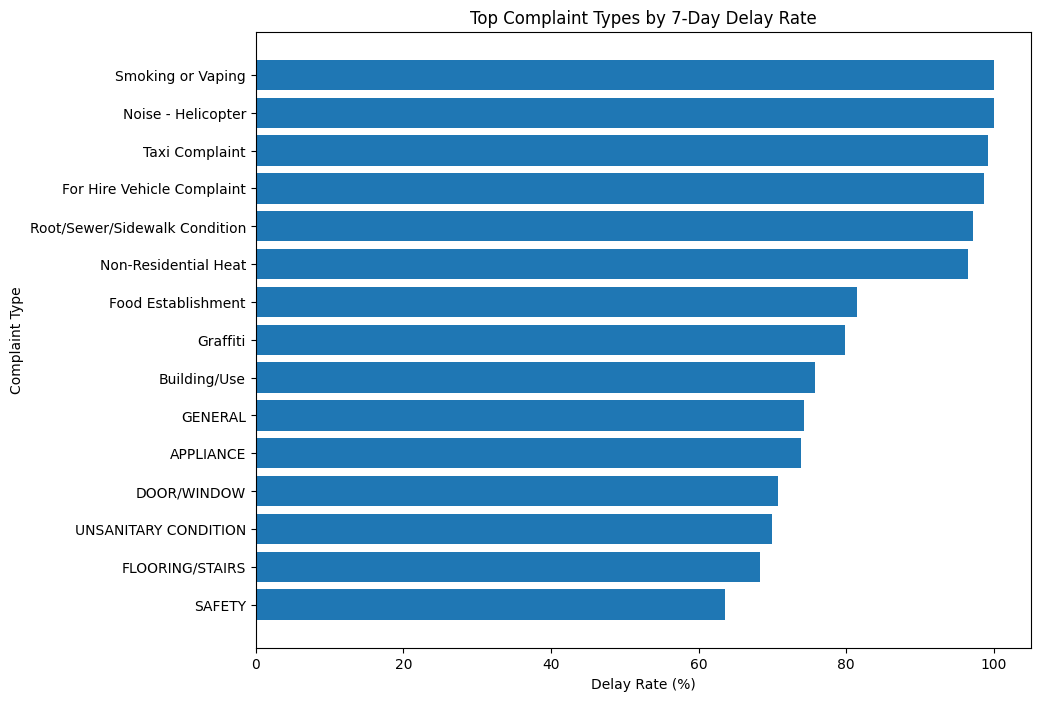

In [24]:
top_delayed_complaints = complaint_summary_filtered.head(15)

plt.figure(figsize=(10, 8))

plt.barh(
    top_delayed_complaints.index[::-1],
    top_delayed_complaints["delay_rate"][::-1]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Complaint Type")
plt.title("Top Complaint Types by 7-Day Delay Rate")

plt.show()

## 8. Borough Analysis

### 8.1 Request Volume by Borough

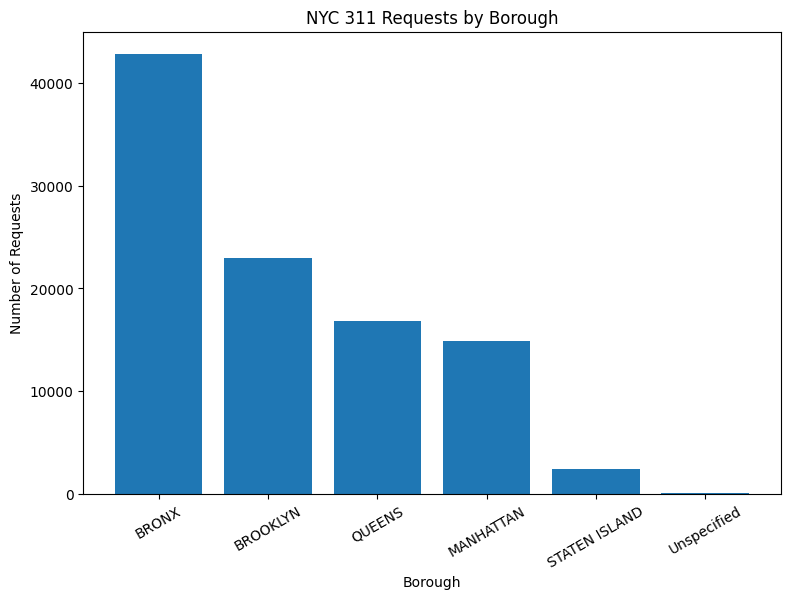

In [25]:
borough_counts = raw["borough"].value_counts()

plt.figure(figsize=(9, 6))

plt.bar(
    borough_counts.index,
    borough_counts.values
)

plt.xlabel("Borough")
plt.ylabel("Number of Requests")
plt.title("NYC 311 Requests by Borough")

plt.xticks(rotation=30)

plt.show()

### 8.2 Delay Rate by Borough

In [26]:
borough_summary = (
    pd.DataFrame({
        "borough": raw["borough"],
        "delay_flag": delay_flag
    })
    .groupby("borough")
    .agg(
        total_requests=("delay_flag", "count"),
        delayed_requests=("delay_flag", "sum")
    )
)

borough_summary["delay_rate"] = (
    borough_summary["delayed_requests"]
    / borough_summary["total_requests"]
    * 100
)

borough_summary = borough_summary.sort_values(
    "delay_rate",
    ascending=False
)

borough_summary

,total_requests,delayed_requests,delay_rate
borough,,,
Unspecified,46,16,34.782609
MANHATTAN,14893,2655,17.827167
BROOKLYN,22918,3684,16.074701
STATEN ISLAND,2436,391,16.050903
QUEENS,16821,2106,12.520064
BRONX,42886,3199,7.459311


### 8.3 Visualize Borough Delay Rate

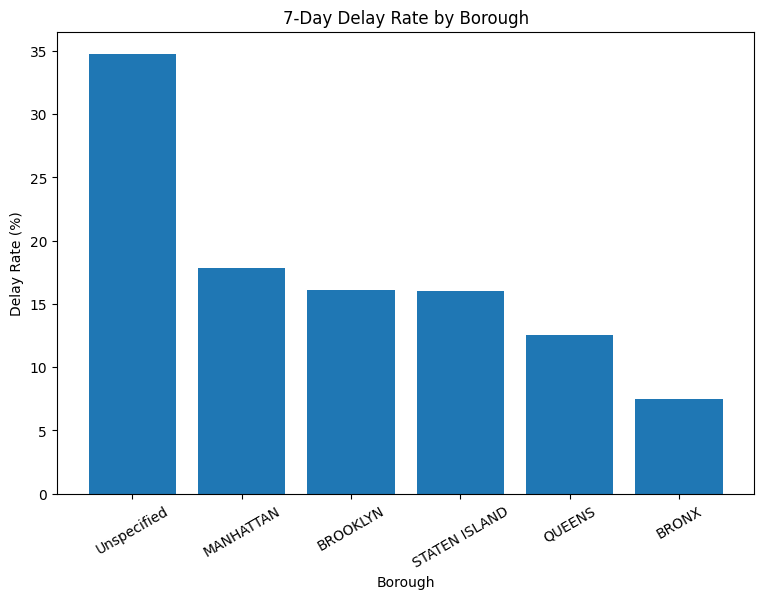

In [27]:
plt.figure(figsize=(9, 6))

plt.bar(
    borough_summary.index,
    borough_summary["delay_rate"]
)

plt.xlabel("Borough")
plt.ylabel("Delay Rate (%)")
plt.title("7-Day Delay Rate by Borough")

plt.xticks(rotation=30)

plt.show()

## 9. Initial Feature Selection

In [28]:
# Initial feature selection summary

feature_summary = pd.DataFrame({
    "feature": [
        "agency",
        "complaint_type",
        "borough",
        "location_type",
        "descriptor",
        "city",
        "incident_zip",
        "latitude",
        "longitude",
        "created_date",
        "closed_date",
        "resolution_days",
        "delay_flag"
    ],
    "role": [
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Candidate feature",
        "Requires feature engineering",
        "Target leakage - exclude",
        "Target leakage - exclude",
        "Target variable"
    ]
})

feature_summary

,feature,role
0,agency,Candidate feature
1,complaint_type,Candidate feature
2,borough,Candidate feature
3,location_type,Candidate feature
4,descriptor,Candidate feature
5,city,Candidate feature
6,incident_zip,Candidate feature
7,latitude,Candidate feature
8,longitude,Candidate feature
9,created_date,Requires feature engineering


In [ ]:
first_experiment_features = [
    "agency"
]

first_experiment_target = "delay_flag"

print("First experiment features:", first_experiment_features)
print("Target:", first_experiment_target)

First experiment features: ['agency']
Target: delay_flag
